# Wine Regression (Deep Learning)
Alcohol 수치(연속값)를 예측하는 딥러닝 모델

※ Regression은 y가 연속적인 숫자 → 원핫인코딩 없음, 출력 뉴런 1개, loss=mse

In [1]:
import pandas as pd
import numpy as np

path = '../../data/wine.csv'

df = pd.read_csv(path)

# Regression: Alcohol(도수)를 예측 대상(y)으로 사용
X = df.drop('Alcohol', axis=1)
y = df['Alcohol']

print(y.describe())

count    178.000000
mean      13.000618
std        0.811827
min       11.030000
25%       12.362500
50%       13.050000
75%       13.677500
max       14.830000
Name: Alcohol, dtype: float64


Epoch 1/50


c:\Users\kiw60\Desktop\intro-to-ai\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 172.7105 - mae: 13.1130 - val_loss: 164.8622 - val_mae: 12.8051
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 162.9467 - mae: 12.7369 - val_loss: 157.5267 - val_mae: 12.5154
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 155.3882 - mae: 12.4373 - val_loss: 150.2607 - val_mae: 12.2220
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 146.1503 - mae: 12.0595 - val_loss: 142.4288 - val_mae: 11.8979
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 137.3150 - mae: 11.6896 - val_loss: 133.4370 - val_mae: 11.5143
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 125.9458 - mae: 11.1883 - val_loss: 122.9222 - val_mae: 11.0489
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 114.3903 - mae: 10.6407 - val_loss: 110.7783 - val_mae: 10.4844
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 99.6189 - mae: 9.9221 - val_loss: 96.8133 - val_mae: 9.7933
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

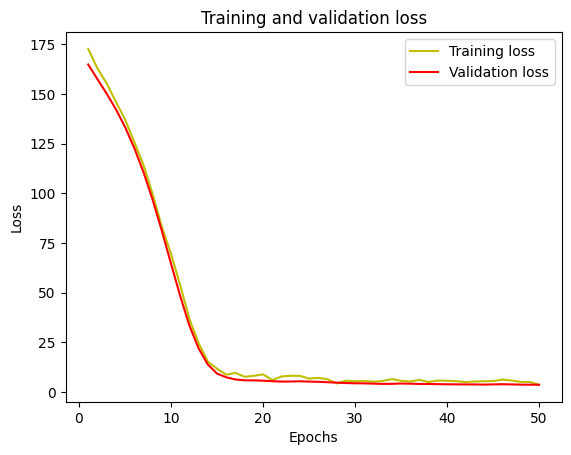

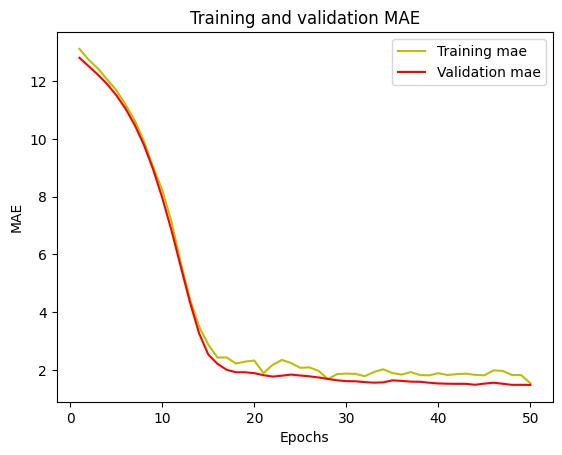

MSE  : 3.1994
MAE  : 1.5136
R²   : -3.6794


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scaler = StandardScaler()
X = scaler.fit_transform(X)   # numpy 배열로 변환됨

# Regression은 원핫인코딩 없음 → y를 numpy 배열로만 변환
Y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)   # Regression: 뉴런 1개, 활성화 함수 없음(linear)
])

model.compile(
    optimizer="adam",
    loss="mse",        # Regression 손실함수: Mean Squared Error
    metrics=["mae"]    # 평가지표: Mean Absolute Error
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test).flatten()

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

plt.plot(epochs_range, loss, 'y', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

mae = history.history['mae']
val_mae = history.history['val_mae']
plt.plot(epochs_range, mae, 'y', label='Training mae')
plt.plot(epochs_range, val_mae, 'r', label='Validation mae')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Accuracy of the predicted values
print(f'MSE  : {mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R²   : {r2_score(y_test, y_pred):.4f}')